In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert

In [36]:
data = ert.load('Line10_notopo.dat')
data["k"] = ert.geometricFactors(data)
print(data)

09/01/26 - 11:45:20 - pyGIMLi - INFO - could not read unified data format for ERT ... try res2dinv


Data: Sensors: 130 data: 2688, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'rhoa', 'valid']


In [37]:
ex = pg.x(data)
print(min(ex), max(ex))
bnd = 1000
world = mt.createWorld(start=[min(ex)-bnd, -bnd, -bnd], end=[max(ex)+bnd, bnd, 0], marker=1)
sea = mt.createCube(start=[min(ex)-bnd, 100, -10], end=[max(ex)+bnd, bnd, 0], marker=2, boundaryMarker=True)

0.0 1290.0


In [48]:
geo = world + sea
for sen in data.sensors():
    geo.createNode(sen)

mesh = mt.createMesh(geo, quality=1.3)
print(mesh)
mesh.populate("res", {1:10, 2:0.2})

Mesh: Nodes: 40752 Cells: 195967 Boundaries: 408493


195967 [0.2,...,10.0]

c:\software\miniforge\envs\pgdev\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vuetify' from 'trame.widgets' (c:\software\miniforge\envs\pgdev\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


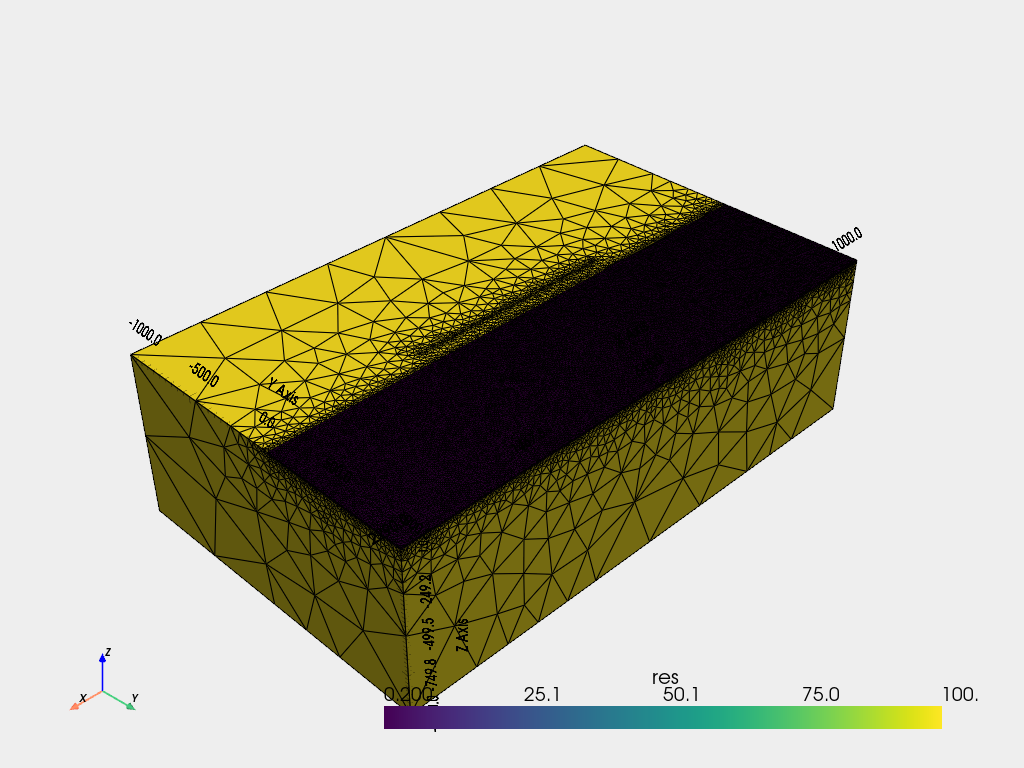

In [41]:
pl, _ = pg.show(mesh, showMesh=True)

In [49]:
data = ert.simulate(mesh, scheme=data, res=mesh["res"])

In [55]:
data.remove(data["rhoa"] <= 0)
data.save('Line10_sea_simulated.dat', 'a b m n k rhoa')

1

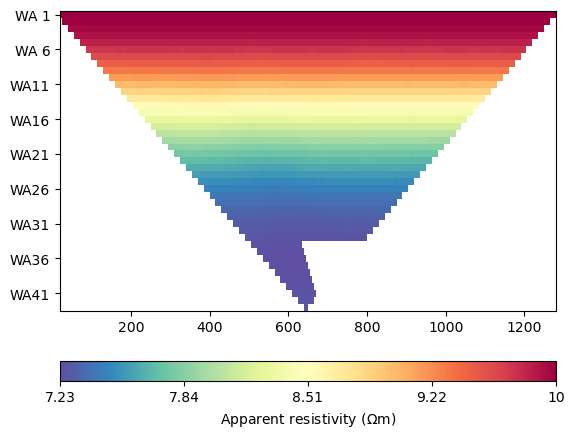

In [56]:
ert.show(data);